In [1]:
##Customer Churn & Retention Analysis
## A subscription company is losing customers every month
## Lets find out the Customer Curn by given data

In [1]:
import pandas as pd
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt

In [67]:
df = pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\Preparation\Project 2\Telco - Customer Churn.xlsx")

In [68]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,One year,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,One year,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,Fiber optic,Month-to-month,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 13)

In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       7043 non-null   object 
 1   gender           7043 non-null   object 
 2   SeniorCitizen    7043 non-null   int64  
 3   Partner          7043 non-null   object 
 4   Dependents       7043 non-null   object 
 5   tenure           7043 non-null   int64  
 6   PhoneService     7043 non-null   object 
 7   InternetService  7043 non-null   object 
 8   Contract         7043 non-null   object 
 9   PaymentMethod    7043 non-null   object 
 10  MonthlyCharges   7043 non-null   float64
 11  TotalCharges     7043 non-null   object 
 12  Churn            7043 non-null   object 
dtypes: float64(1), int64(2), object(10)
memory usage: 715.4+ KB


In [11]:
##Cleaning the data
##Check misssing values
df.isnull().sum()

customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
InternetService    0
Contract           0
PaymentMethod      0
MonthlyCharges     0
TotalCharges       0
Churn              0
dtype: int64

In [13]:
df.isnull().sum().sort_values(ascending = False)

customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
InternetService    0
Contract           0
PaymentMethod      0
MonthlyCharges     0
TotalCharges       0
Churn              0
dtype: int64

In [16]:
df["TotalCharges"].value_counts().head()

         11
20.2     11
19.75     9
20.05     8
19.9      8
Name: TotalCharges, dtype: int64

In [17]:
df[df["TotalCharges"]== " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,DSL,Two year,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,Two year,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,DSL,Two year,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,No,Two year,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,DSL,Two year,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,Two year,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,No,Two year,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,Two year,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,One year,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,DSL,Two year,Mailed check,73.35,,No


In [69]:
df["TotalCharges"].dtype

dtype('O')

In [70]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [20]:
df['TotalCharges'].isnull().sum()

11

In [71]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [73]:
df['TotalCharges'].dtype

dtype('float64')

In [72]:
##Check Duplicates
df['customerID'].duplicated().sum()

0

In [27]:
## Check missing values across all columns
df.isnull().sum()

customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
InternetService    0
Contract           0
PaymentMethod      0
MonthlyCharges     0
TotalCharges       0
Churn              0
dtype: int64

In [74]:
##Encode Churn as numeric
#df.head()
df['Churn_flag'] = df['Churn'].map({'Yes':1, 'No':0})

In [39]:
##Step 3
##Overall Churn rate
churn_rate = df['Churn_flag'].mean()*100
round(churn_rate,2)

26.54

In [40]:
churn_rate = df['Churn_flag'].mean()*100
print(f"Overall Churn percentage: {churn_rate:.2f}%")

Overall Churn percentage: 26.54%


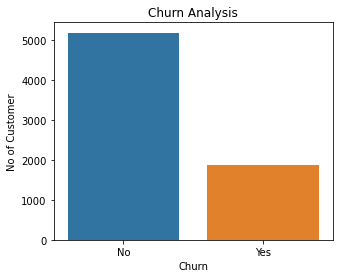

In [75]:
##Visually Churn distribution

plt.figure(figsize =(5,4))
sb.countplot(data = df,x = 'Churn')
plt.xlabel('Churn')
plt.ylabel('No of Customer')
plt.title('Churn Analysis')
plt.show()

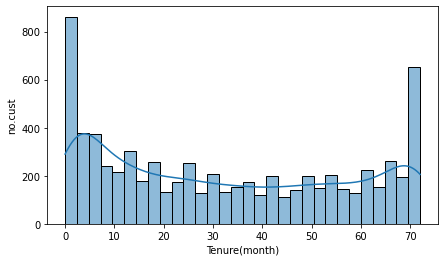

In [77]:
##Distribution of Tenure
plt.figure(figsize = (7,4))
sb.histplot(df['tenure'],bins = 30, kde = True)
plt.xlabel('Tenure(month)')
plt.ylabel('no.cust')
plt.show()

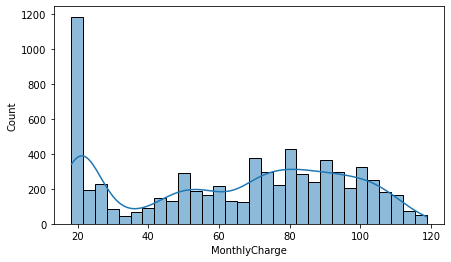

In [78]:
##Distribution of Monthy charges
plt.figure(figsize = (7,4))
sb.histplot(df['MonthlyCharges'], bins = 30, kde = True)
plt.xlabel('MonthlyCharge')
plt.show()

In [79]:
##Step 4
#CHurn rate by contract type
Contract_churn = df.groupby('Contract')['Churn_flag'].mean()*100
Contract_churn

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn_flag, dtype: float64

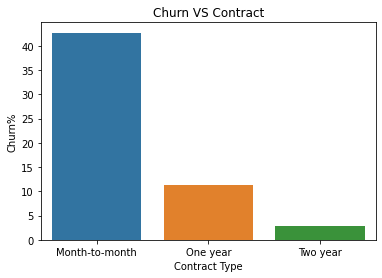

In [80]:
##Visualize the Churn rate by contract
plt.figure(figsize = (6,4))
sb.barplot(x=Contract_churn.index, y= Contract_churn.values)
plt.ylabel('Churn%')
plt.xlabel('Contract Type')
plt.title('Churn VS Contract')
plt.show()

In [13]:
##Churn Rate by Payment Method
Payment_churn = df.groupby('PaymentMethod')['Churn_flag'].mean()*100
Payment_churn

PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Churn_flag, dtype: float64

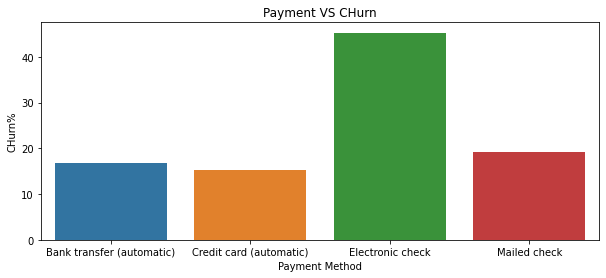

In [18]:
plt.figure(figsize= (10,4))
sb.barplot(x=Payment_churn.index,y=Payment_churn.values)
plt.ylabel('CHurn%')
plt.xlabel('Payment Method')
plt.title('Payment VS CHurn')
plt.show()

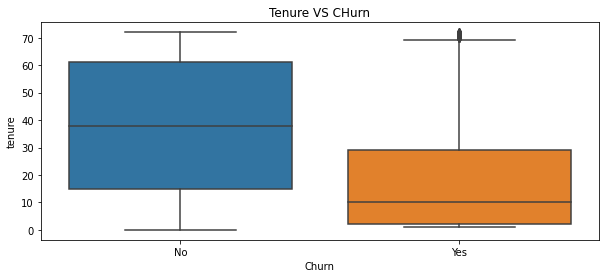

In [81]:
## Visualize Tenure vs Churn

plt.figure(figsize= (10,4))
sb.boxplot(data=df,x = 'Churn', y= 'tenure')
plt.title('Tenure VS CHurn')
plt.show()

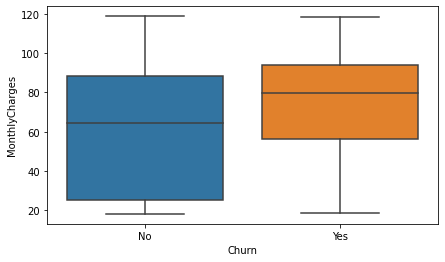

In [82]:
##Visualize Monthlycharges vs Churn
plt.figure(figsize = (7,4))
sb.boxplot(data = df,x = 'Churn', y = 'MonthlyCharges')
plt.show()

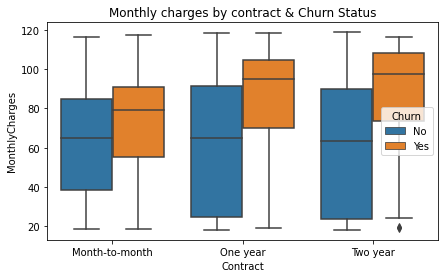

In [83]:
## comparision Visual of Contract, Monthlycharges & CHurn
plt.figure(figsize=(7,4))
sb.boxplot(data = df, x = 'Contract', y = 'MonthlyCharges',hue = 'Churn')
plt.title('Monthly charges by contract & Churn Status')
plt.show()

In [84]:
##Internet Service Type vs Churn
service_churn = df.groupby('InternetService')['Churn_flag'].mean()*100
service_churn

InternetService
DSL            18.959108
Fiber optic    41.892765
No              7.404980
Name: Churn_flag, dtype: float64

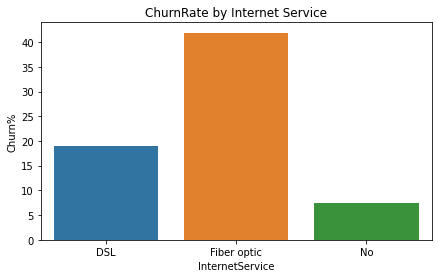

In [29]:
##Visualize Service Vs CHurn
plt.figure(figsize=(7,4))
sb.barplot(x=service_churn.index, y=service_churn.values)
plt.ylabel('Churn%')
plt.title('ChurnRate by Internet Service')
plt.show()

In [85]:
#df.head()
#Step 5 = Correlation & Relationship Analysis
##Correlation - only works on numbers
numeric_cols = ['tenure','MonthlyCharges','TotalCharges','Churn_flag','SeniorCitizen']
corr_matrix = df[numeric_cols].corr()
corr_matrix

,tenure,MonthlyCharges,TotalCharges,Churn_flag,SeniorCitizen
tenure,1.000000,0.247900,0.826178,-0.352229,0.016567
MonthlyCharges,0.247900,1.000000,0.651174,0.193356,0.220173
TotalCharges,0.826178,0.651174,1.000000,-0.198324,0.103006
Churn_flag,-0.352229,0.193356,-0.198324,1.000000,0.150889
SeniorCitizen,0.016567,0.220173,0.103006,0.150889,1.000000


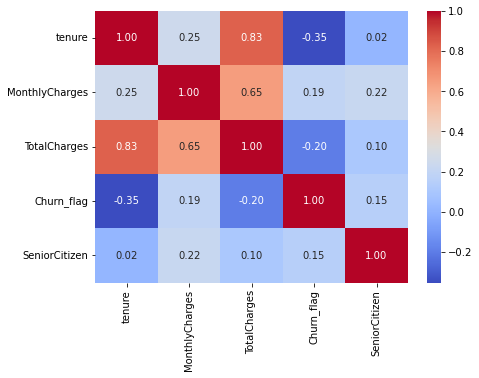

In [86]:
##Visualize the Correlation
plt.figure(figsize = (7,5))
sb.heatmap(data = corr_matrix, annot = True, cmap = 'coolwarm',fmt = '.2f')
plt.show()

In [87]:
## ^ values range= -=0 to 1+ 
## 1+ shows Strong relationship
## -1 shows negative relationship
## 0  shows No relationship

## Tenure usually shows a negative relationship with Churn_flag = -0.35
## Monthlycharges usually shows a small positive relationship with Churn_flag = 0.19
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,Month-to-month,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,One year,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Month-to-month,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,DSL,One year,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,Fiber optic,Month-to-month,Electronic check,70.70,151.65,Yes,1


In [88]:
## Crosstab for catagorical variables(Correlation doesn't work on text categories)
## Contract vs Churn = show count and percentages
pd.crosstab(df['Contract'],df['Churn'],normalize = 'index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [41]:
##PaymentMethod vs Churn
pd.crosstab(df['PaymentMethod'],df['Churn'], normalize = 'index')*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [45]:
##Internet Service Vs CHurn
pd.crosstab(df['InternetService'],df['Churn'], normalize = 'index')*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [46]:
## PhoneService vs CHurn
pd.crosstab(df['PhoneService'],df['Churn'],normalize = 'index')*100

Churn,No,Yes
PhoneService,,
No,75.073314,24.926686
Yes,73.290363,26.709637


In [89]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'InternetService',
 'Contract',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'Churn_flag']

In [90]:
## Combine key churn rate into one summary table
summary = pd.DataFrame({'ChurnRate':df.groupby('Contract')['Churn_flag'].mean(),}).sort_values('ChurnRate',ascending = False)
summary*100

,ChurnRate
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


In [53]:
summary_2 = df.groupby('Contract')['Churn_flag'].mean()*100
summary_2

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn_flag, dtype: float64

In [57]:
summary_3 = df.pivot_table(index = 'Contract', values = 'Churn_flag', aggfunc = 'mean')
summary_3*100

,Churn_flag
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


In [91]:
##Export the cleaned data
df.to_csv('telco_churn_cleaned.csv', index = False)

In [92]:
Check = pd.read_csv('telco_churn_cleaned.csv')
Check.info()
Check.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       7043 non-null   object 
 1   gender           7043 non-null   object 
 2   SeniorCitizen    7043 non-null   int64  
 3   Partner          7043 non-null   object 
 4   Dependents       7043 non-null   object 
 5   tenure           7043 non-null   int64  
 6   PhoneService     7043 non-null   object 
 7   InternetService  7043 non-null   object 
 8   Contract         7043 non-null   object 
 9   PaymentMethod    7043 non-null   object 
 10  MonthlyCharges   7043 non-null   float64
 11  TotalCharges     7043 non-null   float64
 12  Churn            7043 non-null   object 
 13  Churn_flag       7043 non-null   int64  
dtypes: float64(2), int64(3), object(9)
memory usage: 770.5+ KB


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,Month-to-month,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,One year,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Month-to-month,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,DSL,One year,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,Fiber optic,Month-to-month,Electronic check,70.70,151.65,Yes,1


In [3]:
import pandas as pd

In [4]:
df4 = pd.read_csv(r"C:\Users\HP\Downloads\Case Study - DA\telco_churn_cleaned.csv")

In [6]:
df4.head()
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customerID       7043 non-null   object 
 1   gender           7043 non-null   object 
 2   SeniorCitizen    7043 non-null   int64  
 3   Partner          7043 non-null   object 
 4   Dependents       7043 non-null   object 
 5   tenure           7043 non-null   int64  
 6   PhoneService     7043 non-null   object 
 7   InternetService  7043 non-null   object 
 8   Contract         7043 non-null   object 
 9   PaymentMethod    7043 non-null   object 
 10  MonthlyCharges   7043 non-null   float64
 11  TotalCharges     7043 non-null   float64
 12  Churn            7043 non-null   object 
 13  Churn_flag       7043 non-null   int64  
dtypes: float64(2), int64(3), object(9)
memory usage: 770.5+ KB
